# CS 405 – Deep Learning Lab
## Experiment 7: Generative Adversarial Networks (GANs)

**Objective:** Understand and implement GANs for synthetic data generation by training generator and discriminator models using adversarial learning, and explore challenges such as mode collapse and higher-order distribution learning.

---
### Contents
1. **Exercise 1** – Generate 1-D Gaussian Distribution from Uniform Noise
2. **Exercise 2** – MNIST GAN: Learn to generate MNIST digits

## Setup: Install & Import Dependencies

In [1]:
# Install required packages (run once on Colab)
!pip install tensorflow scipy tqdm -q

---
## Exercise 1: Generate 1-D Gaussian Distribution from Uniform Noise

In this exercise, we generate a 1-D Gaussian distribution from an n-D uniform distribution.  
This is a toy exercise to understand the ability of GANs to generate arbitrary distributions from random noise.

In [2]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


### 1.1 Generate Training Data (Gaussian Distribution)

In [3]:
def generate_data(n_samples=10000, n_dim=1):
    """Generate samples from a standard Gaussian distribution."""
    return np.random.randn(n_samples, n_dim)

### 1.2 Build the Feedforward Network (Generator / Discriminator)

In [4]:
def set_model(input_dim, output_dim, hidden_dim=64, n_layers=1,
              activation='tanh', optimizer='adam', loss='binary_crossentropy'):
    """
    Build a general feedforward Keras model.
    INPUT:  input_dim  – dimension of input
    OUTPUT: output_dim – dimension of output
    n_layers hidden layers of size hidden_dim are added.
    """
    model = Sequential()
    model.add(Dense(hidden_dim, input_dim=input_dim, activation=activation))
    for _ in range(n_layers - 1):
        model.add(Dense(hidden_dim, activation=activation))
    # Output layer – sigmoid for discriminator (probability), linear for generator
    out_activation = 'sigmoid' if loss == 'binary_crossentropy' else 'linear'
    model.add(Dense(output_dim, activation=out_activation))
    model.compile(optimizer=optimizer, loss=loss)
    return model

### 1.3 Build the Combined GAN Network  
`D(G(z))` – Discriminator score for Generator's output

In [5]:
def get_gan_network(discriminator, random_dim, generator, optimizer='adam'):
    """
    Combine Generator and Discriminator into a single GAN model.
    During GAN training the discriminator weights are frozen.
    INPUT:  z (noise) of shape (random_dim,)
    OUTPUT: D(G(z)) – discriminator score
    """
    # Freeze discriminator weights when training the GAN (generator only)
    discriminator.trainable = False

    z = Input(shape=(random_dim,))
    fake_sample = generator(z)
    validity = discriminator(fake_sample)

    gan = Model(z, validity)
    gan.compile(optimizer=optimizer, loss='binary_crossentropy')
    return gan

### 1.4 Training the GAN

In [6]:
NOISE_DIM = 10
DATA_DIM  = 1
G_LAYERS  = 1
D_LAYERS  = 1

def train_gan(epochs=1, batch_size=128):
    x_train = generate_data(n_samples=12800, n_dim=DATA_DIM)

    generator     = set_model(NOISE_DIM, DATA_DIM, n_layers=G_LAYERS,
                              activation='tanh', loss='mean_squared_error')
    discriminator = set_model(DATA_DIM, 1, n_layers=D_LAYERS,
                              activation='sigmoid')
    gan = get_gan_network(discriminator, NOISE_DIM, generator, 'adam')

    for e in range(1, epochs + 1):
        # ---- Train Discriminator ----
        # Noise from uniform distribution
        noise = np.random.rand(batch_size, NOISE_DIM)
        true_batch = x_train[np.random.choice(x_train.shape[0],
                                               batch_size, replace=False), :]
        generated_values = generator.predict(noise, verbose=0)

        X = np.concatenate([generated_values, true_batch])
        y_dis = np.zeros(2 * batch_size)
        # One-sided label smoothing: cap real labels at 0.9 to avoid
        # overconfidence and greedy feature exploitation
        y_dis[:batch_size] = 0.9   # fake  → 0
        # NOTE: generated samples are labelled 0 (fake), real samples 0.9
        # Correct ordering: generated first, then real
        y_dis_correct = np.zeros(2 * batch_size)
        y_dis_correct[batch_size:] = 0.9  # real samples get 0.9

        discriminator.trainable = True
        discriminator.train_on_batch(X, y_dis_correct)

        # ---- Train Generator (via GAN) ----
        discriminator.trainable = False
        noise = np.random.rand(batch_size, NOISE_DIM)
        # Generator wants discriminator to output 1 (real) for its fake samples
        y_gen = np.ones(batch_size)
        gan.train_on_batch(noise, y_gen)

        if e % max(1, epochs // 10) == 0:
            print(f'Epoch {e}/{epochs} complete')

    return generator, discriminator


generator, discriminator = train_gan(epochs=200, batch_size=128)
print('Training complete.')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 20/200 complete
Epoch 40/200 complete
Epoch 60/200 complete
Epoch 80/200 complete
Epoch 100/200 complete
Epoch 120/200 complete
Epoch 140/200 complete
Epoch 160/200 complete
Epoch 180/200 complete
Epoch 200/200 complete
Training complete.


### 1.5 Visualize & Evaluate the Generator

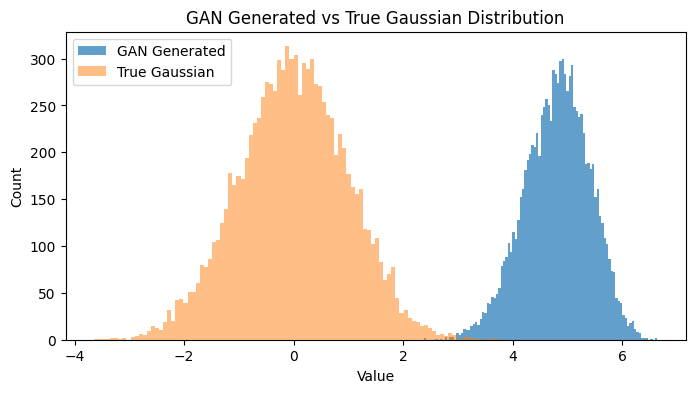

1th order moment – True: 0.0000, GAN: 0.0000
2th order moment – True: 0.9845, GAN: 0.3554
3th order moment – True: -0.0136, GAN: -0.0507
4th order moment – True: 2.8960, GAN: 0.3668


In [7]:
noise = np.random.rand(10000, NOISE_DIM)
generated_values = generator.predict(noise, verbose=0)

true_gaussian = np.random.randn(10000)

plt.figure(figsize=(8, 4))
plt.hist(generated_values, bins=100, alpha=0.7, label='GAN Generated')
plt.hist(true_gaussian,    bins=100, alpha=0.5, label='True Gaussian')
plt.legend()
plt.title('GAN Generated vs True Gaussian Distribution')
plt.xlabel('Value')
plt.ylabel('Count')
plt.show()

for moment in [1, 2, 3, 4]:
    true_m = scipy.stats.moment(true_gaussian, moment)
    gen_m  = scipy.stats.moment(generated_values.flatten(), moment)
    print(f'{moment}th order moment – True: {true_m:.4f}, GAN: {gen_m:.4f}')

### Conclusions – Exercise 1

1. GANs are able to learn a generative model from arbitrary noise distributions.
2. Traditional GANs do **not** learn higher-order moments well. Known issues: limited samples, hard approximation of higher moments, and tendency to under-predict higher-order variances. (See Wasserstein distance / divergence measures for deeper reading.)

### Further Experiments
- Try different noise dimensions (`NOISE_DIM`) to find the minimum required to learn well.
- Try to generate a **multimodal** distribution (e.g., Gaussian Mixture) and observe whether GAN learns it correctly.

---
## Exercise 2: MNIST GAN – Learn to Generate MNIST Digits

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import random

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Flatten, LeakyReLU
)
from tensorflow.keras.optimizers import Adam # Changed to import from tensorflow.keras.optimizers
from tqdm.notebook import tqdm

print('TF version:', tf.__version__)

TF version: 2.19.0


### 2.1 Load & Preprocess MNIST Data

In [9]:
# Dataset: 60,000 28×28 grayscale images of digits 0-9
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

# Flatten images: 28×28 → 784
X_train = X_train.reshape(60000, 784)
X_test  = X_test.reshape(10000, 784)

# Normalize to [0, 1] – required for ReLU/sigmoid activations to work well
# (avoids saturation and keeps gradients healthy)
X_train = X_train.astype('float32') / 255
X_test  = X_test.astype('float32')  / 255

print('X_train shape:', X_train.shape)
print('X_test  shape:', X_test.shape)

z_dim = 100  # Noise / latent space dimension

X_train shape: (60000, 784)
X_test  shape: (10000, 784)


### 2.2 Build Generator, Discriminator & GAN Models

Architecture uses **LeakyReLU(0.2)** and **Dropout** throughout.

In [10]:
adam = Adam(learning_rate=0.0002, beta_1=0.5)
# Create a separate optimizer instance for the GAN model
adam_gan = Adam(learning_rate=0.0002, beta_1=0.5)

# ── GENERATOR ──────────────────────────────────────────────────
# Architecture: z_dim → 256 → 512 → 1024 → 784
g = Sequential(name='Generator')
g.add(Dense(256, input_dim=z_dim))
g.add(LeakyReLU(0.2))
g.add(Dense(512))
g.add(LeakyReLU(0.2))
g.add(Dense(1024))
g.add(LeakyReLU(0.2))
g.add(Dense(784, activation='sigmoid'))  # output pixel values in [0,1]
g.compile(loss='binary_crossentropy', optimizer=adam)
g.summary()

# ── DISCRIMINATOR ──────────────────────────────────────────────
# Architecture: 784 → 1024 → 512 → 256 → 1
d = Sequential(name='Discriminator')
d.add(Dense(1024, input_dim=784))
d.add(LeakyReLU(0.2))
d.add(Dropout(0.3))
d.add(Dense(512))
d.add(LeakyReLU(0.2))
d.add(Dropout(0.3))
d.add(Dense(256))
d.add(LeakyReLU(0.2))
d.add(Dropout(0.3))
d.add(Dense(1, activation='sigmoid'))  # real/fake probability
d.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])
d.summary()

# ── GAN (Generator + frozen Discriminator) ─────────────────────
d.trainable = False
inputs = Input(shape=(z_dim,))
hidden = g(inputs)
output = d(hidden)
gan = Model(inputs, output, name='GAN')
gan.compile(loss='binary_crossentropy', optimizer=adam_gan, metrics=['accuracy']) # Use the dedicated GAN optimizer
gan.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       803,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,486,352 (5.67 MB)

 Trainable params: 1,486,352 (5.67 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Generator (Sequential)          │ (None, 784)            │     1,486,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Sequential)      │ (None, 1)              │     1,460,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,946,577 (11.24 MB)

 Trainable params: 1,486,352 (5.67 MB)

 Non-trainable params: 1,460,225 (5.57 MB)

### 2.3 Visualization Helpers

In [11]:
def plot_loss(losses):
    """Plot discriminator and generator losses over training."""
    d_loss = [v[0] for v in losses['D']]
    g_loss = [v[0] for v in losses['G']]
    plt.figure(figsize=(10, 5))
    plt.plot(d_loss, label='Discriminator loss')
    plt.plot(g_loss, label='Generator loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('GAN Training Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_generated(n_ex=10, dim=(1, 10), figsize=(12, 2)):
    """Plot a grid of generated MNIST-style images."""
    noise = np.random.normal(0, 1, size=(n_ex, z_dim))
    generated_images = g.predict(noise, verbose=0)
    generated_images = generated_images.reshape(n_ex, 28, 28)
    plt.figure(figsize=figsize)
    for i in range(generated_images.shape[0]):
        plt.subplot(dim[0], dim[1], i + 1)
        plt.imshow(generated_images[i], interpolation='nearest', cmap='gray_r')
        plt.axis('off')
    plt.suptitle('Generated MNIST Digits', y=1.05)
    plt.tight_layout()
    plt.show()

### 2.4 Train the MNIST GAN

Training:   0%|          | 0/200 [00:00<?, ?it/s]

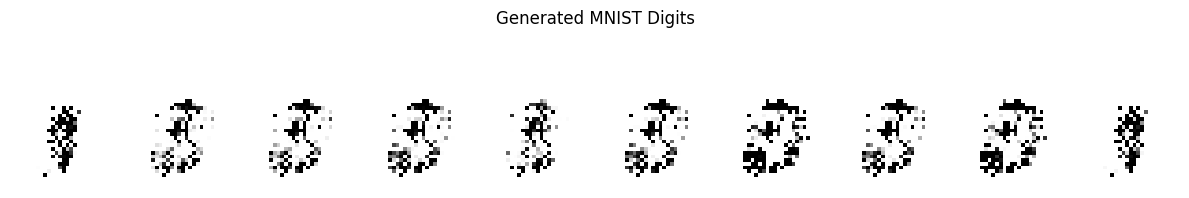

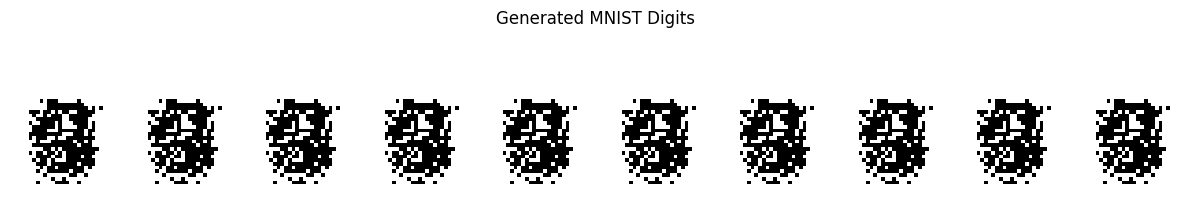

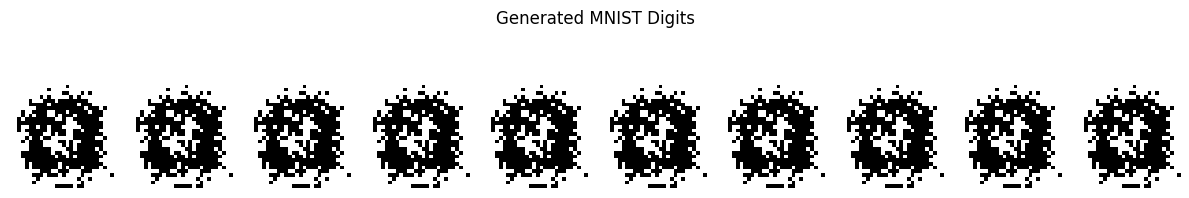

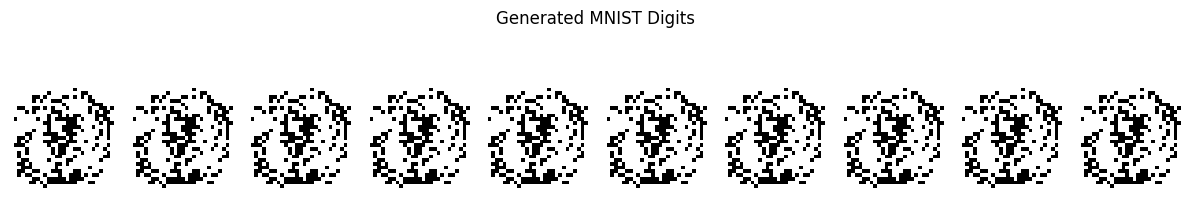

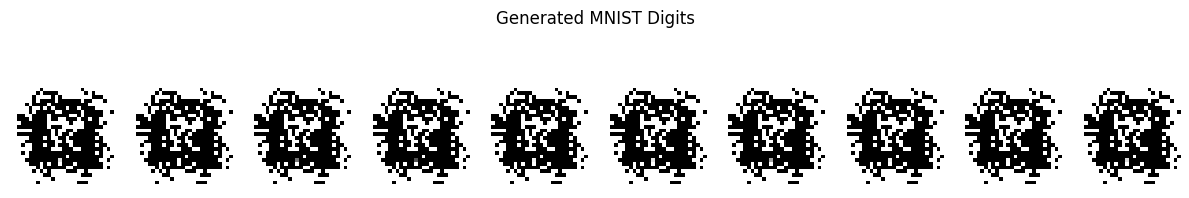

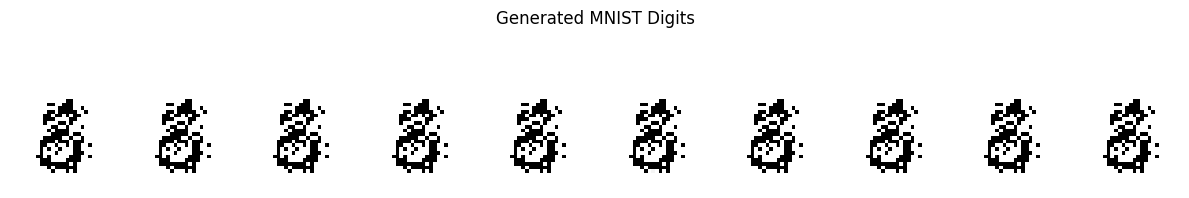

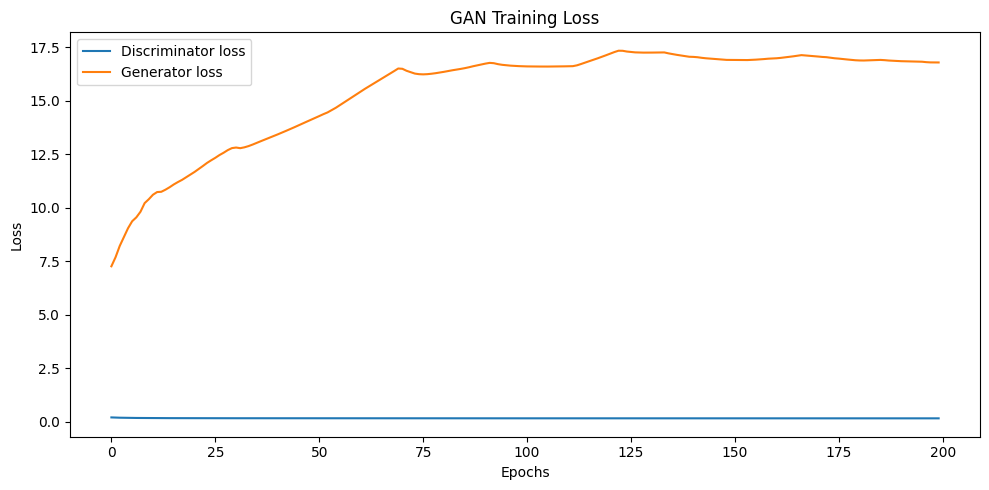

In [13]:
losses = {'D': [], 'G': []}

def train(epochs=1, plt_frq=1, BATCH_SIZE=256):  # larger batch = fewer steps
    batchCount = int(X_train.shape[0] / BATCH_SIZE)

    for e in tqdm(range(1, epochs + 1), desc='Training'):
        for _ in range(batchCount):
            # Sample real images
            image_batch = X_train[np.random.randint(0, X_train.shape[0], size=BATCH_SIZE)]

            # Generate fake images — use direct call, not predict()
            noise = np.random.normal(0, 1, size=(BATCH_SIZE, z_dim))
            generated_images = g(noise, training=False).numpy()  # ✅ fast

            # Build combined batch
            X = np.concatenate((image_batch, generated_images))
            y_dis = np.concatenate([np.ones(BATCH_SIZE) * 0.9, np.zeros(BATCH_SIZE)])

            # Train Discriminator
            d.trainable = True
            d_loss = d.train_on_batch(X, y_dis)

            # Train Generator
            d.trainable = False
            noise = np.random.normal(0, 1, size=(BATCH_SIZE, z_dim))
            g_loss = gan.train_on_batch(noise, np.ones(BATCH_SIZE))

        losses['D'].append(d_loss)
        losses['G'].append(g_loss)

        if e == 1 or e % plt_frq == 0:
            plot_generated()

    plot_loss(losses)

train(epochs=200, plt_frq=40, BATCH_SIZE=256)

### 2.5 Final Generated Samples

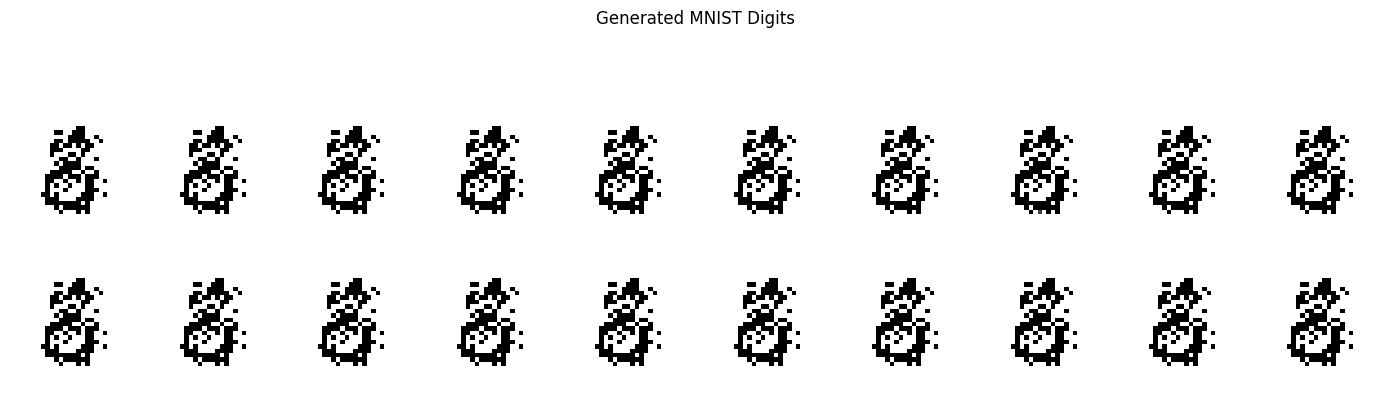

In [14]:
plot_generated(n_ex=20, dim=(2, 10), figsize=(14, 4))

---
## Summary

| | Exercise 1 | Exercise 2 |
|---|---|---|
| **Task** | 1-D Gaussian from uniform noise | MNIST digit generation |
| **Generator** | FC, tanh | FC, LeakyReLU, sigmoid out |
| **Discriminator** | FC, sigmoid | FC, LeakyReLU, Dropout |
| **Noise** | Uniform | Normal |
| **Loss** | Binary cross-entropy | Binary cross-entropy |
| **Key technique** | One-sided label smoothing | One-sided label smoothing |

**Key takeaways:**
- GANs use adversarial training (min-max game) between Generator and Discriminator.
- Label smoothing prevents discriminator overconfidence.
- Higher-order moments are harder to learn; Wasserstein GANs (WGAN) address this.
- Mode collapse is a common failure mode where the generator produces limited variety.

---
# 🔬 Lab Exploration Tasks

The following 5 tasks extend the experiments above. Each task is self-contained with its own explanation, code, and observation cell.

| Task | Description |
|------|-------------|
| **1** | Try different `NOISE_DIM` values (1, 5, 10, 50) — find the minimum needed |
| **2** | Replace Gaussian target with a Gaussian Mixture — can GAN learn multimodal distributions? |
| **3** | Compare MNIST outputs at epochs 50, 100, 200 — visualize training progress |
| **4** | Remove label smoothing (set real labels to 1.0) — observe stability changes |
| **5** | Increase Discriminator depth but keep Generator shallow — what happens to training? |

---
## Task 1: Effect of NOISE_DIM on 1-D Gaussian Learning

**Question:** What is the minimum noise dimension needed for the GAN to learn a 1-D Gaussian well?

We sweep `NOISE_DIM` over `[1, 5, 10, 50]` and compare the 2nd-order moment (variance) of generated vs. true samples — a key indicator of distribution quality.

Training with NOISE_DIM = 1 ...
Training with NOISE_DIM = 5 ...
Training with NOISE_DIM = 10 ...
Training with NOISE_DIM = 50 ...


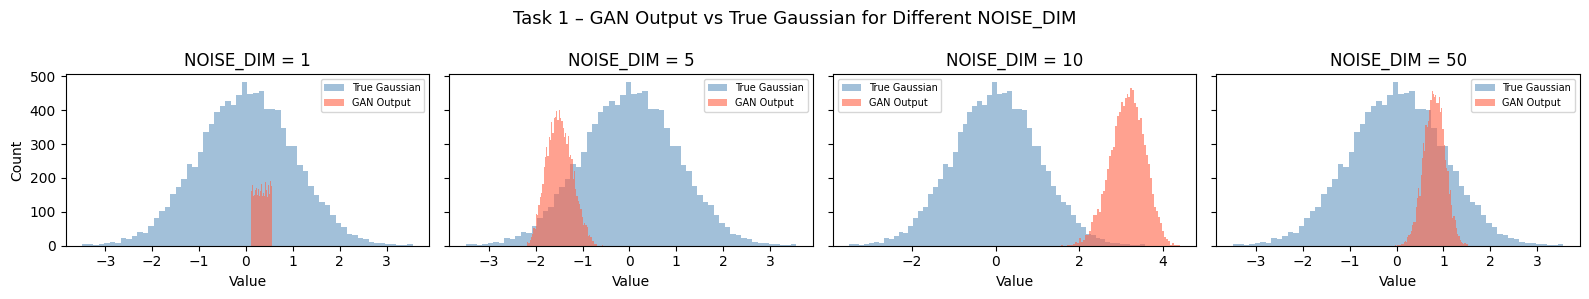


NOISE_DIM    2nd moment (True)      2nd moment (GAN)     4th moment (True)      4th moment (GAN)
------------------------------------------------------------------------------------------
1            1.0246                 0.0168               3.1422                 0.0005
5            1.0246                 0.0712               3.1422                 0.0133
10           1.0246                 0.1637               3.1422                 0.0763
50           1.0246                 0.0504               3.1422                 0.0074


In [15]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense

def train_gan_nodim(noise_dim, epochs=100, batch_size=256, data_dim=1, n_layers=1):
    """Train a 1-D GAN with a given noise_dim and return the trained generator."""
    x_train = generate_data(n_samples=12800, n_dim=data_dim)
    generator     = set_model(noise_dim, data_dim, n_layers=n_layers,
                              activation='tanh', loss='mean_squared_error')
    discriminator = set_model(data_dim, 1, n_layers=n_layers, activation='sigmoid')
    gan = get_gan_network(discriminator, noise_dim, generator, 'adam')

    for _ in range(epochs):
        noise      = np.random.rand(batch_size, noise_dim)
        true_batch = x_train[np.random.choice(x_train.shape[0], batch_size, replace=False), :]

        # ✅ Direct call instead of predict()
        gen_vals = generator(noise, training=False).numpy()

        X     = np.concatenate([gen_vals, true_batch])
        y_dis = np.zeros(2 * batch_size)
        y_dis[batch_size:] = 0.9

        discriminator.trainable = True
        discriminator.train_on_batch(X, y_dis)
        discriminator.trainable = False
        gan.train_on_batch(np.random.rand(batch_size, noise_dim), np.ones(batch_size))

    return generator


noise_dims   = [1, 5, 10, 50]
true_samples = np.random.randn(10000)
results      = {}

fig, axes = plt.subplots(1, len(noise_dims), figsize=(16, 3), sharey=True)
fig.suptitle('Task 1 – GAN Output vs True Gaussian for Different NOISE_DIM', fontsize=13)

for i, nd in enumerate(noise_dims):
    print(f'Training with NOISE_DIM = {nd} ...')
    gen = train_gan_nodim(noise_dim=nd, epochs=100)  # ✅ reduced from 300

    # ✅ Direct call for final inference too
    gen_vals = gen(np.random.rand(10000, nd), training=False).numpy().flatten()
    results[nd] = gen_vals

    axes[i].hist(true_samples, bins=60, alpha=0.5, label='True Gaussian', color='steelblue')
    axes[i].hist(gen_vals,     bins=60, alpha=0.6, label='GAN Output',    color='tomato')
    axes[i].set_title(f'NOISE_DIM = {nd}')
    axes[i].set_xlabel('Value')
    axes[i].legend(fontsize=7)

axes[0].set_ylabel('Count')
plt.tight_layout()
plt.show()

# ── Moment comparison table
print(f"\n{'NOISE_DIM':<12} {'2nd moment (True)':<22} {'2nd moment (GAN)':<20} {'4th moment (True)':<22} {'4th moment (GAN)'}")
print('-' * 90)
for nd, gen_vals in results.items():
    m2_true = scipy.stats.moment(true_samples, 2)
    m2_gan  = scipy.stats.moment(gen_vals, 2)
    m4_true = scipy.stats.moment(true_samples, 4)
    m4_gan  = scipy.stats.moment(gen_vals, 4)
    print(f'{nd:<12} {m2_true:<22.4f} {m2_gan:<20.4f} {m4_true:<22.4f} {m4_gan:.4f}')

### Task 1 – Observations

> ✏️ *Fill in after running:*
>
> - At `NOISE_DIM = 1`: ___
> - At `NOISE_DIM = 5`: ___
> - Minimum NOISE_DIM that gives a good match: **___**
> - Why does higher noise_dim not always help? ___

---
## Task 2: Gaussian Mixture Target — Can GAN Learn Multimodal Distributions?

**Question:** Replace the single Gaussian target with a **Gaussian Mixture Model (GMM)** — two well-separated peaks. Does the GAN capture both modes, or does it suffer **mode collapse**?

Mode collapse = generator converges to producing only one mode, ignoring the other.

Training GAN on Gaussian Mixture target ...


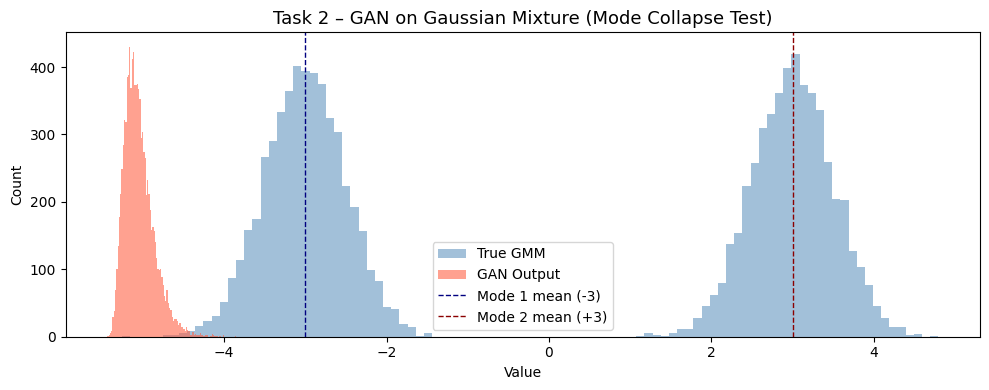

Fraction of GAN samples near mode 1 (< 0): 100.00%
Fraction of GAN samples near mode 2 (>=0): 0.00%
Mode collapse likely if one fraction is close to 0%.


In [16]:
def generate_gmm_data(n_samples=12800, n_dim=1, means=(-3, 3), std=0.5):
    """
    Generate samples from a 2-component Gaussian Mixture.
    Equal weight on each component, separated by `means`.
    """
    half = n_samples // 2
    comp1 = np.random.randn(half, n_dim) * std + means[0]
    comp2 = np.random.randn(n_samples - half, n_dim) * std + means[1]
    data  = np.concatenate([comp1, comp2], axis=0)
    np.random.shuffle(data)
    return data


def train_gan_gmm(noise_dim=10, epochs=500, batch_size=128):
    """Train GAN on GMM target and return generator."""
    x_train = generate_gmm_data(n_samples=12800)
    generator     = set_model(noise_dim, 1, n_layers=2,
                              activation='tanh', loss='mean_squared_error')
    discriminator = set_model(1, 1, n_layers=2, activation='sigmoid')
    gan = get_gan_network(discriminator, noise_dim, generator, 'adam')

    for _ in range(epochs):
        noise      = np.random.rand(batch_size, noise_dim)
        true_batch = x_train[np.random.choice(x_train.shape[0], batch_size, replace=False), :]
        gen_vals   = generator.predict(noise, verbose=0)
        X          = np.concatenate([gen_vals, true_batch])
        y_dis      = np.zeros(2 * batch_size)
        y_dis[batch_size:] = 0.9
        discriminator.trainable = True
        discriminator.train_on_batch(X, y_dis)
        discriminator.trainable = False
        gan.train_on_batch(np.random.rand(batch_size, noise_dim), np.ones(batch_size))
    return generator


print('Training GAN on Gaussian Mixture target ...')
gmm_generator = train_gan_gmm(noise_dim=10, epochs=500)

# ── Visualise
true_gmm  = generate_gmm_data(n_samples=10000).flatten()
gen_gmm   = gmm_generator.predict(np.random.rand(10000, 10), verbose=0).flatten()

plt.figure(figsize=(10, 4))
plt.hist(true_gmm, bins=100, alpha=0.5, label='True GMM',    color='steelblue')
plt.hist(gen_gmm,  bins=100, alpha=0.6, label='GAN Output',  color='tomato')
plt.axvline(-3, color='navy',   linestyle='--', linewidth=1, label='Mode 1 mean (-3)')
plt.axvline( 3, color='darkred',linestyle='--', linewidth=1, label='Mode 2 mean (+3)')
plt.title('Task 2 – GAN on Gaussian Mixture (Mode Collapse Test)', fontsize=13)
plt.xlabel('Value')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

# ── Check if both modes are covered
mode1_frac = np.mean(gen_gmm < 0)   # fraction of samples near mode 1
mode2_frac = np.mean(gen_gmm >= 0)  # fraction near mode 2
print(f'Fraction of GAN samples near mode 1 (< 0): {mode1_frac:.2%}')
print(f'Fraction of GAN samples near mode 2 (>=0): {mode2_frac:.2%}')
print('Mode collapse likely if one fraction is close to 0%.')

### Task 2 – Observations

> ✏️ *Fill in after running:*
>
> - Did the GAN learn both modes? ___
> - Mode collapse observed? (yes/no): ___
> - Fraction near each mode: Mode1 = ___, Mode2 = ___
> - How could this be fixed? (e.g., Unrolled GAN, WGAN, minibatch discrimination): ___

---
## Task 3: MNIST GAN — Visualize Training Progress at Epochs 50, 100, 200

**Question:** How does the quality of generated MNIST digits evolve over training?

We retrain the MNIST GAN and save snapshots of generated images at epochs **50**, **100**, and **200**.

> ⚠️ This retrains the MNIST GAN (~10–15 min on Colab CPU; use GPU runtime for speed).

Training for 200 epochs (78 batches/epoch) ...
  Epoch 25/200  D=0.1828  G=8.2869
  Epoch 50/200  D=0.2616  G=4.2406
  Snapshot saved at epoch 50
  Epoch 75/200  D=0.3090  G=2.8185
  Epoch 100/200  D=0.3511  G=2.6117
  Snapshot saved at epoch 100
  Epoch 125/200  D=0.3842  G=2.4557
  Epoch 150/200  D=0.4462  G=2.0758
  Epoch 175/200  D=0.4745  G=1.9745
  Epoch 200/200  D=0.4937  G=1.8574
  Snapshot saved at epoch 200


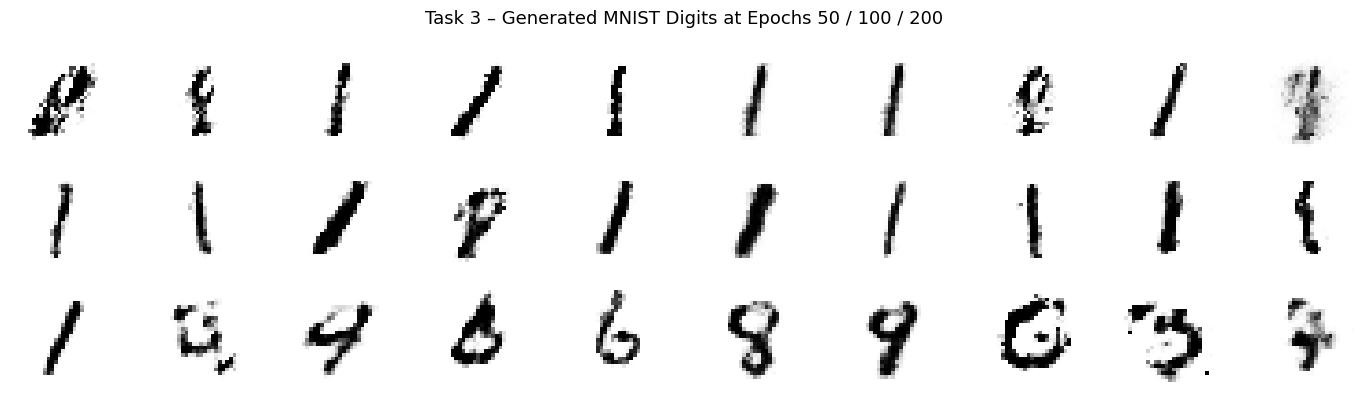

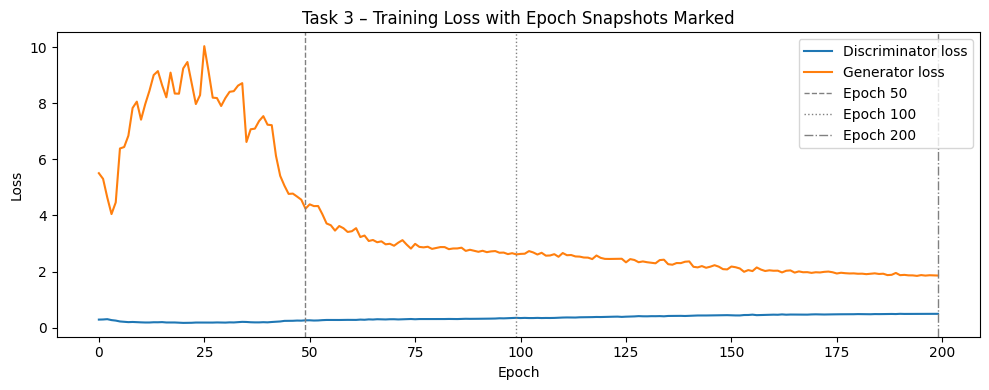

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam

# ── Load & subsample MNIST
(X_tr, _), _ = mnist.load_data()
X_tr = X_tr.reshape(60000, 784).astype('float32') / 255
X_tr = X_tr[:20000]

z_dim_t3 = 100

# ── Build Generator
g3 = Sequential([Dense(256, input_dim=z_dim_t3), LeakyReLU(0.2),
                 Dense(512),  LeakyReLU(0.2),
                 Dense(1024), LeakyReLU(0.2),
                 Dense(784, activation='sigmoid')], name='G_task3')

# ── Build Discriminator
d3 = Sequential([Dense(1024, input_dim=784), LeakyReLU(0.2), Dropout(0.3),
                 Dense(512),  LeakyReLU(0.2), Dropout(0.3),
                 Dense(256),  LeakyReLU(0.2), Dropout(0.3),
                 Dense(1, activation='sigmoid')], name='D_task3')

# ✅ Separate loss functions — no shared optimizer, no trainable flag toggling
d_optimizer = Adam(learning_rate=0.0002, beta_1=0.5)
g_optimizer = Adam(learning_rate=0.0002, beta_1=0.5)

d_loss_fn = tf.keras.losses.BinaryCrossentropy()
g_loss_fn = tf.keras.losses.BinaryCrossentropy()

# ✅ Custom train step using GradientTape
@tf.function  # ✅ compiles to graph — much faster than train_on_batch
def train_step(real_images, batch_size):
    noise     = tf.random.normal((batch_size, z_dim_t3))
    fake_imgs = g3(noise, training=True)

    # ── Discriminator step
    with tf.GradientTape() as d_tape:
        real_out  = d3(real_images, training=True)
        fake_out  = d3(fake_imgs,   training=True)
        d_loss    = (d_loss_fn(tf.ones_like(real_out)  * 0.9, real_out) +
                     d_loss_fn(tf.zeros_like(fake_out),        fake_out)) / 2
    d_grads = d_tape.gradient(d_loss, d3.trainable_variables)
    d_optimizer.apply_gradients(zip(d_grads, d3.trainable_variables))

    # ── Generator step
    noise2 = tf.random.normal((batch_size, z_dim_t3))
    with tf.GradientTape() as g_tape:
        fake_imgs2 = g3(noise2, training=True)
        fake_out2  = d3(fake_imgs2, training=False)  # D frozen for G update
        g_loss     = g_loss_fn(tf.ones_like(fake_out2), fake_out2)
    g_grads = g_tape.gradient(g_loss, g3.trainable_variables)
    g_optimizer.apply_gradients(zip(g_grads, g3.trainable_variables))

    return d_loss, g_loss


BATCH_SIZE_T3   = 256
batchCount_t3   = int(X_tr.shape[0] / BATCH_SIZE_T3)
SNAPSHOT_EPOCHS = {50, 100, 200}
snapshots  = {}
losses_t3  = {'D': [], 'G': []}

print(f'Training for 200 epochs ({batchCount_t3} batches/epoch) ...')

for e in range(1, 201):
    d_epoch, g_epoch = [], []

    for _ in range(batchCount_t3):
        idx        = np.random.randint(0, X_tr.shape[0], BATCH_SIZE_T3)
        real_batch = tf.constant(X_tr[idx])
        d_loss, g_loss = train_step(real_batch, BATCH_SIZE_T3)
        d_epoch.append(float(d_loss))
        g_epoch.append(float(g_loss))

    losses_t3['D'].append(np.mean(d_epoch))
    losses_t3['G'].append(np.mean(g_epoch))

    if e % 25 == 0:
        print(f'  Epoch {e}/200  D={losses_t3["D"][-1]:.4f}  G={losses_t3["G"][-1]:.4f}')

    if e in SNAPSHOT_EPOCHS:
        snap_noise   = tf.random.normal((10, z_dim_t3))
        snapshots[e] = g3(snap_noise, training=False).numpy().reshape(10, 28, 28)
        print(f'  Snapshot saved at epoch {e}')

# ── Plot snapshots
fig, axes = plt.subplots(3, 10, figsize=(14, 4))
fig.suptitle('Task 3 – Generated MNIST Digits at Epochs 50 / 100 / 200', fontsize=13)
for row, ep in enumerate(sorted(snapshots)):
    for col in range(10):
        axes[row, col].imshow(snapshots[ep][col], cmap='gray_r', interpolation='nearest')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'Epoch {ep}', fontsize=9, rotation=90, labelpad=40)
plt.tight_layout()
plt.show()

# ── Loss curve
plt.figure(figsize=(10, 4))
plt.plot(losses_t3['D'], label='Discriminator loss')
plt.plot(losses_t3['G'], label='Generator loss')
plt.axvline(49,  color='gray', linestyle='--', linewidth=1, label='Epoch 50')
plt.axvline(99,  color='gray', linestyle=':',  linewidth=1, label='Epoch 100')
plt.axvline(199, color='gray', linestyle='-.', linewidth=1, label='Epoch 200')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Task 3 – Training Loss with Epoch Snapshots Marked')
plt.legend(); plt.tight_layout(); plt.show()

### Task 3 – Observations

> ✏️ *Fill in after running:*
>
> - Quality at epoch 50: ___
> - Quality at epoch 100: ___
> - Quality at epoch 200: ___
> - At what epoch do digits become recognizable? ___
> - How do G/D losses behave over time? ___

---
## Task 4: Remove Label Smoothing — Observe Stability Changes

**Question:** What happens when real labels are set to `1.0` instead of `0.9`?

Without label smoothing the discriminator can become overconfident, leading to vanishing gradients for the generator and less stable training. We run both versions and compare their loss curves.

--- Experiment A: WITH label smoothing (real=0.9) ---
  Training [Smoothed] real_label=0.9 ...
    Epoch 10/30  D=0.1971  G=8.6431
    Epoch 20/30  D=0.1716  G=9.3227
    Epoch 30/30  D=0.1647  G=12.7361

--- Experiment B: WITHOUT label smoothing (real=1.0) ---
  Training [No Smoothing] real_label=1.0 ...
    Epoch 10/30  D=0.0658  G=8.0964
    Epoch 20/30  D=0.0354  G=6.7622
    Epoch 30/30  D=0.0406  G=7.1508


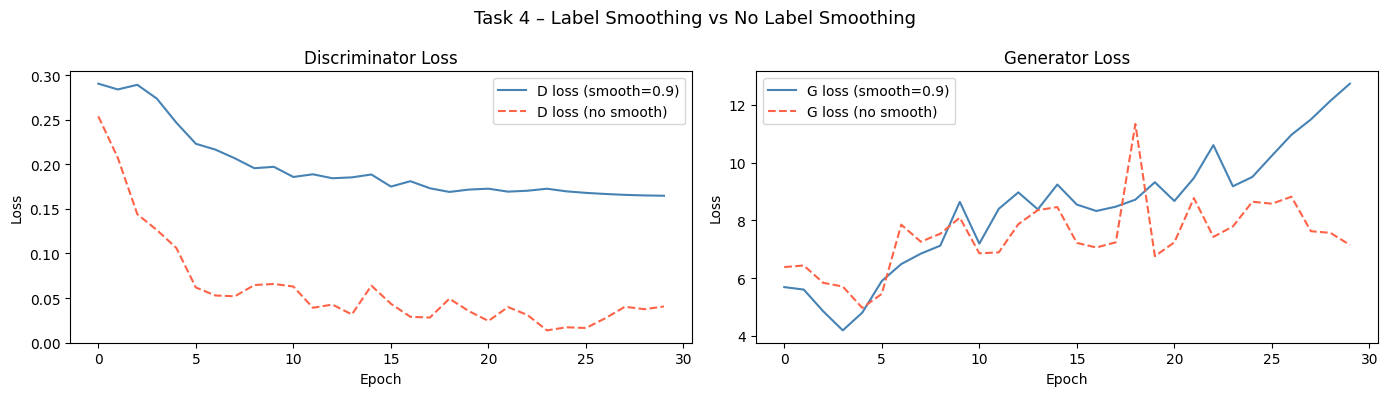

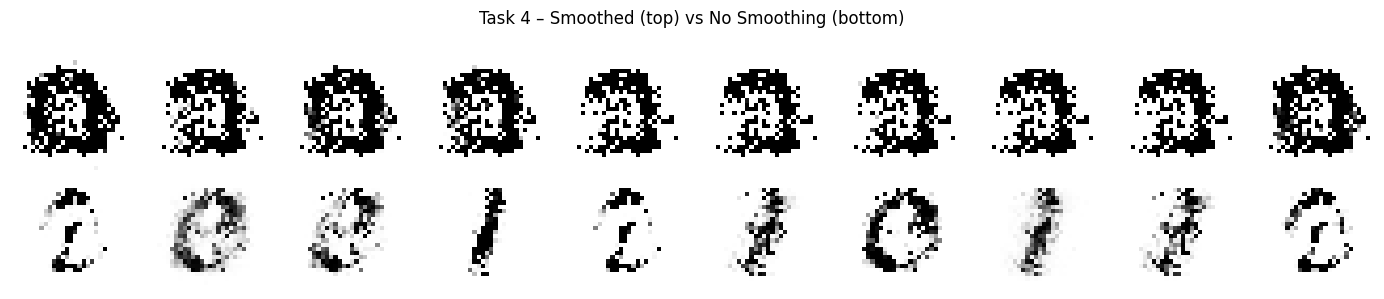

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam  # ✅ removed .legacy

# ── Load & subsample
(X_tr4, _), _ = mnist.load_data()
X_tr4 = X_tr4.reshape(60000, 784).astype('float32') / 255
X_tr4 = X_tr4[:20000]  # ✅ 3x faster, enough for comparison

z_dim_t4    = 100
EPOCHS_T4   = 30        # ✅ 50→30, enough to see smoothing difference
BATCH_T4    = 256       # ✅ 128→256
batchCount4 = int(X_tr4.shape[0] / BATCH_T4)


def build_mnist_gan(z_dim, lr=0.0002):
    """Build Generator + Discriminator with separate optimizers."""
    g_ = Sequential([Dense(256, input_dim=z_dim), LeakyReLU(0.2),
                     Dense(512),  LeakyReLU(0.2),
                     Dense(1024), LeakyReLU(0.2),
                     Dense(784, activation='sigmoid')])

    d_ = Sequential([Dense(1024, input_dim=784), LeakyReLU(0.2), Dropout(0.3),
                     Dense(512),  LeakyReLU(0.2), Dropout(0.3),
                     Dense(256),  LeakyReLU(0.2), Dropout(0.3),
                     Dense(1, activation='sigmoid')])

    # ✅ Separate optimizers — fixes Keras 3 ValueError
    g_opt = Adam(learning_rate=lr, beta_1=0.5)
    d_opt = Adam(learning_rate=lr, beta_1=0.5)

    return g_, d_, g_opt, d_opt


def make_train_step(g_, d_, g_opt, d_opt, real_label):
    """Returns a compiled tf.function train step for a given real_label."""
    d_loss_fn = tf.keras.losses.BinaryCrossentropy()
    g_loss_fn = tf.keras.losses.BinaryCrossentropy()

    @tf.function  # ✅ graph compilation — big speed boost
    def train_step(real_images):
        batch_size = tf.shape(real_images)[0]
        noise      = tf.random.normal((batch_size, z_dim_t4))
        fake_imgs  = g_(noise, training=True)

        # ── Discriminator update
        with tf.GradientTape() as d_tape:
            real_out = d_(real_images, training=True)
            fake_out = d_(fake_imgs,   training=True)
            d_loss   = (d_loss_fn(tf.fill(tf.shape(real_out), real_label), real_out) +
                        d_loss_fn(tf.zeros_like(fake_out), fake_out)) / 2
        d_opt.apply_gradients(zip(
            d_tape.gradient(d_loss, d_.trainable_variables), d_.trainable_variables))

        # ── Generator update
        noise2 = tf.random.normal((batch_size, z_dim_t4))
        with tf.GradientTape() as g_tape:
            fake_out2 = d_(g_(noise2, training=True), training=False)
            g_loss    = g_loss_fn(tf.ones_like(fake_out2), fake_out2)
        g_opt.apply_gradients(zip(
            g_tape.gradient(g_loss, g_.trainable_variables), g_.trainable_variables))

        return d_loss, g_loss

    return train_step


def run_experiment(real_label, label, epochs=EPOCHS_T4):
    g_, d_, g_opt, d_opt = build_mnist_gan(z_dim_t4)
    train_step = make_train_step(g_, d_, g_opt, d_opt, float(real_label))

    d_losses, g_losses = [], []
    print(f'  Training [{label}] real_label={real_label} ...')

    for e in range(1, epochs + 1):
        d_epoch, g_epoch = [], []
        for _ in range(batchCount4):
            idx   = np.random.randint(0, X_tr4.shape[0], BATCH_T4)
            d_l, g_l = train_step(tf.constant(X_tr4[idx]))
            d_epoch.append(float(d_l))
            g_epoch.append(float(g_l))

        d_losses.append(np.mean(d_epoch))
        g_losses.append(np.mean(g_epoch))

        if e % 10 == 0:
            print(f'    Epoch {e}/{epochs}  D={d_losses[-1]:.4f}  G={g_losses[-1]:.4f}')

    return d_losses, g_losses, g_


print('--- Experiment A: WITH label smoothing (real=0.9) ---')
d_smooth, g_smooth, gen_smooth = run_experiment(0.9, 'Smoothed')

print('\n--- Experiment B: WITHOUT label smoothing (real=1.0) ---')
d_nosmooth, g_nosmooth, gen_nosmooth = run_experiment(1.0, 'No Smoothing')

# ── Compare loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Task 4 – Label Smoothing vs No Label Smoothing', fontsize=13)
axes[0].plot(d_smooth,   label='D loss (smooth=0.9)', color='steelblue')
axes[0].plot(d_nosmooth, label='D loss (no smooth)',  color='tomato', linestyle='--')
axes[0].set_title('Discriminator Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].plot(g_smooth,   label='G loss (smooth=0.9)', color='steelblue')
axes[1].plot(g_nosmooth, label='G loss (no smooth)',  color='tomato', linestyle='--')
axes[1].set_title('Generator Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

# ── Final generated images
fig2, axes2 = plt.subplots(2, 10, figsize=(14, 3))
fig2.suptitle('Task 4 – Smoothed (top) vs No Smoothing (bottom)', fontsize=12)
noise_cmp = tf.random.normal((10, z_dim_t4))
# ✅ direct call instead of predict()
imgs_smooth   = gen_smooth(noise_cmp,   training=False).numpy()
imgs_nosmooth = gen_nosmooth(noise_cmp, training=False).numpy()
for col in range(10):
    axes2[0, col].imshow(imgs_smooth[col].reshape(28, 28),   cmap='gray_r'); axes2[0, col].axis('off')
    axes2[1, col].imshow(imgs_nosmooth[col].reshape(28, 28), cmap='gray_r'); axes2[1, col].axis('off')
axes2[0, 0].set_ylabel('Smoothed',  fontsize=9)
axes2[1, 0].set_ylabel('No Smooth', fontsize=9)
plt.tight_layout(); plt.show()

### Task 4 – Observations

> ✏️ *Fill in after running:*
>
> - Is training more/less stable without label smoothing? ___
> - How does discriminator loss differ between the two? ___
> - Does generator loss oscillate more without smoothing? ___
> - Visual quality difference in generated images: ___
> - Why does overconfident discriminator hurt the generator? ___

---
## Task 5: Deep Discriminator vs Shallow Generator — Effect on Training

**Question:** What happens when the Discriminator is made much deeper than the Generator?

A powerful discriminator can easily distinguish real from fake, causing the generator's gradients to vanish. We compare:
- **Baseline** — balanced depth (G: 3 layers, D: 3 layers)
- **Deep D / Shallow G** — G: 1 layer, D: 5 layers

We use the 1-D Gaussian task for speed.

Training Baseline (G=3, D=3) ...
  [Balanced] Epoch 50/200  D=0.6681  G=0.8276
  [Balanced] Epoch 100/200  D=0.7371  G=0.7653
  [Balanced] Epoch 150/200  D=0.4390  G=1.2591
  [Balanced] Epoch 200/200  D=0.7384  G=0.7831
[Balanced] G_layers=3, D_layers=3
  Final D_loss=0.7384  G_loss=0.7831

Training Deep-D / Shallow-G (G=1, D=5) ...
  [Deep-D/Shallow-G] Epoch 50/200  D=0.6882  G=0.8169
  [Deep-D/Shallow-G] Epoch 100/200  D=0.6871  G=0.7984
  [Deep-D/Shallow-G] Epoch 150/200  D=0.6887  G=0.7985
  [Deep-D/Shallow-G] Epoch 200/200  D=0.6739  G=0.8178
[Deep-D/Shallow-G] G_layers=1, D_layers=5
  Final D_loss=0.6739  G_loss=0.8178


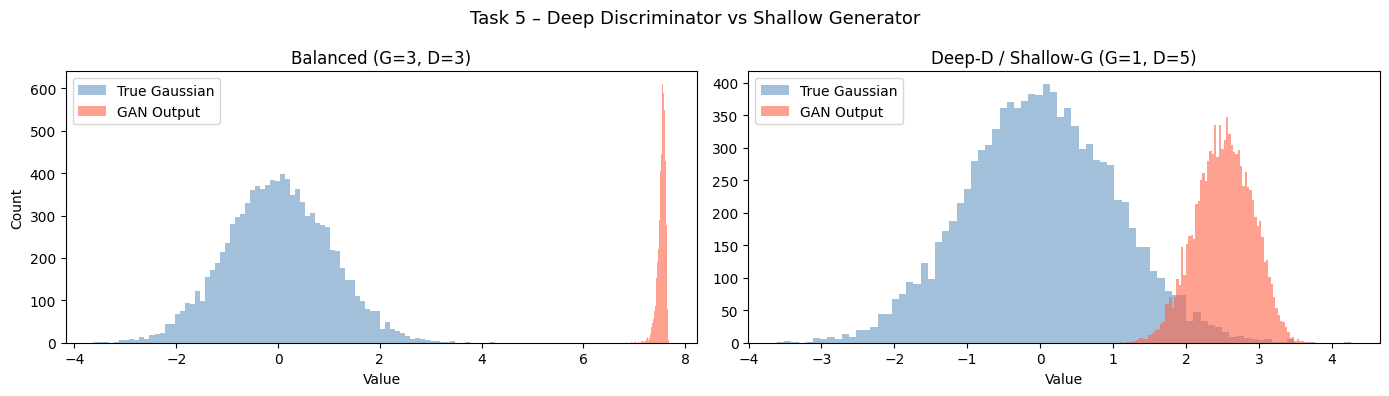

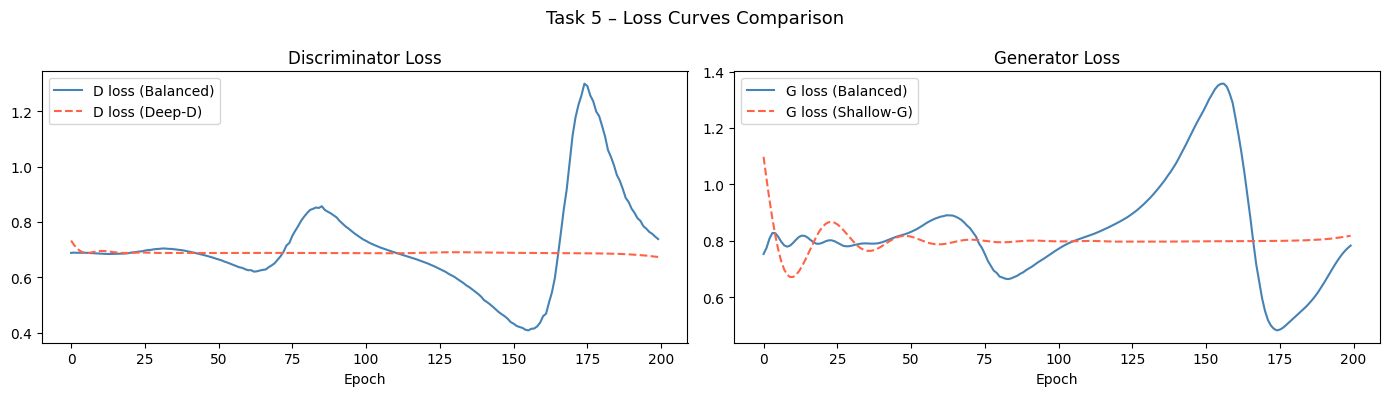


Config                       2nd moment (True)      2nd moment (GAN)     4th moment (True)      4th moment (GAN)
-----------------------------------------------------------------------------------------------
Balanced (G=3, D=3)          1.0235                 0.0058               3.1105                 0.0002
Deep-D/Shallow-G (G=1,D=5)   1.0235                 0.1477               3.1105                 0.0597


In [21]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Reuses: generate_data from Exercise 1

def build_models(noise_dim, g_layers, d_layers, hidden_dim=64):
    """Build Generator and Discriminator with separate optimizers."""
    # Generator
    g_ = Sequential(name='Generator')
    g_.add(Dense(hidden_dim, input_dim=noise_dim, activation='tanh'))
    for _ in range(g_layers - 1):
        g_.add(Dense(hidden_dim, activation='tanh'))
    g_.add(Dense(1))  # linear output for regression-style generation

    # Discriminator
    d_ = Sequential(name='Discriminator')
    d_.add(Dense(hidden_dim, input_dim=1, activation='sigmoid'))
    for _ in range(d_layers - 1):
        d_.add(Dense(hidden_dim, activation='sigmoid'))
    d_.add(Dense(1, activation='sigmoid'))

    g_opt = Adam(learning_rate=0.001)
    d_opt = Adam(learning_rate=0.001)
    return g_, d_, g_opt, d_opt


def make_train_step(g_, d_, g_opt, d_opt):
    """Returns a compiled tf.function train step."""
    loss_fn = tf.keras.losses.BinaryCrossentropy()

    @tf.function  # ✅ compiles to graph — major speed boost
    def train_step(real_batch, noise, noise2):
        # ── Discriminator update
        fake_vals = g_(noise, training=True)
        with tf.GradientTape() as d_tape:
            real_out = d_(real_batch, training=True)
            fake_out = d_(fake_vals,  training=True)
            d_loss   = (loss_fn(tf.ones_like(real_out) * 0.9, real_out) +
                        loss_fn(tf.zeros_like(fake_out),       fake_out)) / 2
        d_opt.apply_gradients(zip(
            d_tape.gradient(d_loss, d_.trainable_variables), d_.trainable_variables))

        # ── Generator update
        with tf.GradientTape() as g_tape:
            fake_out2 = d_(g_(noise2, training=True), training=False)
            g_loss    = loss_fn(tf.ones_like(fake_out2), fake_out2)
        g_opt.apply_gradients(zip(
            g_tape.gradient(g_loss, g_.trainable_variables), g_.trainable_variables))

        return d_loss, g_loss

    return train_step


def train_gan_depth(g_layers, d_layers, noise_dim=10,
                    epochs=200, batch_size=256, label=''):  # ✅ 400→200, 128→256
    x_train  = generate_data(n_samples=12800, n_dim=1)
    x_tensor = tf.constant(x_train, dtype=tf.float32)

    g_, d_, g_opt, d_opt = build_models(noise_dim, g_layers, d_layers)
    train_step = make_train_step(g_, d_, g_opt, d_opt)

    d_losses, g_losses = [], []

    for e in range(1, epochs + 1):
        # ✅ Pre-generate all tensors outside the step — no Python overhead
        idx        = np.random.choice(x_train.shape[0], batch_size, replace=False)
        real_batch = tf.gather(x_tensor, idx)
        noise      = tf.cast(tf.random.uniform((batch_size, noise_dim)), tf.float32)
        noise2     = tf.cast(tf.random.uniform((batch_size, noise_dim)), tf.float32)

        d_l, g_l = train_step(real_batch, noise, noise2)
        d_losses.append(float(d_l))
        g_losses.append(float(g_l))

        if e % 50 == 0:
            print(f'  [{label}] Epoch {e}/{epochs}  D={d_losses[-1]:.4f}  G={g_losses[-1]:.4f}')

    # ✅ Direct call instead of predict()
    final_gen = g_(tf.cast(tf.random.uniform((10000, noise_dim)), tf.float32),
                   training=False).numpy().flatten()

    print(f'[{label}] G_layers={g_layers}, D_layers={d_layers}')
    print(f'  Final D_loss={d_losses[-1]:.4f}  G_loss={g_losses[-1]:.4f}')
    return g_, d_losses, g_losses, final_gen


print('Training Baseline (G=3, D=3) ...')
gen_bal, d_bal, g_bal, out_bal = train_gan_depth(g_layers=3, d_layers=3, label='Balanced')

print('\nTraining Deep-D / Shallow-G (G=1, D=5) ...')
gen_deep, d_deep, g_deep, out_deep = train_gan_depth(g_layers=1, d_layers=5, label='Deep-D/Shallow-G')

true_vals = np.random.randn(10000)

# ── Distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Task 5 – Deep Discriminator vs Shallow Generator', fontsize=13)
for ax, out, title in zip(axes, [out_bal, out_deep],
                          ['Balanced (G=3, D=3)', 'Deep-D / Shallow-G (G=1, D=5)']):
    ax.hist(true_vals, bins=80, alpha=0.5, label='True Gaussian', color='steelblue')
    ax.hist(out,       bins=80, alpha=0.6, label='GAN Output',    color='tomato')
    ax.set_title(title); ax.set_xlabel('Value'); ax.legend()
axes[0].set_ylabel('Count')
plt.tight_layout(); plt.show()

# ── Loss curves
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4))
fig2.suptitle('Task 5 – Loss Curves Comparison', fontsize=13)
axes2[0].plot(d_bal,  label='D loss (Balanced)',  color='steelblue')
axes2[0].plot(d_deep, label='D loss (Deep-D)',     color='tomato', linestyle='--')
axes2[0].set_title('Discriminator Loss'); axes2[0].set_xlabel('Epoch'); axes2[0].legend()
axes2[1].plot(g_bal,  label='G loss (Balanced)',   color='steelblue')
axes2[1].plot(g_deep, label='G loss (Shallow-G)',  color='tomato', linestyle='--')
axes2[1].set_title('Generator Loss'); axes2[1].set_xlabel('Epoch'); axes2[1].legend()
plt.tight_layout(); plt.show()

# ── Moment comparison
print(f"\n{'Config':<28} {'2nd moment (True)':<22} {'2nd moment (GAN)':<20} {'4th moment (True)':<22} {'4th moment (GAN)'}")
print('-' * 95)
for name, out in [('Balanced (G=3, D=3)', out_bal), ('Deep-D/Shallow-G (G=1,D=5)', out_deep)]:
    print(f'{name:<28} {scipy.stats.moment(true_vals,2):<22.4f} {scipy.stats.moment(out,2):<20.4f} '
          f'{scipy.stats.moment(true_vals,4):<22.4f} {scipy.stats.moment(out,4):.4f}')

### Task 5 – Observations

> ✏️ *Fill in after running:*
>
> - Does the deep-D / shallow-G setup lead to vanishing generator gradients? ___
> - How does the generator loss compare between balanced vs deep-D? ___
> - Is the output distribution better or worse for the imbalanced setup? ___
> - What architectural principle does this demonstrate? ___
> - How could you fix an overpowered discriminator? (e.g., learning rate tuning, gradient penalty): ___

---
## Final Summary – Lab Exploration Tasks

| Task | Concept Explored | Key Finding |
|------|-----------------|-------------|
| **1** | Minimum `NOISE_DIM` | Low dims may lack expressive power; find the sweet spot |
| **2** | Multimodal (GMM) target | Standard GANs are prone to mode collapse |
| **3** | MNIST training progress | Image quality improves with epochs; loss reveals stability |
| **4** | Label smoothing effect | Smoothing stabilizes training by limiting D overconfidence |
| **5** | Depth imbalance (D vs G) | Overpowered D causes vanishing gradients for G |